# Chapter 7: Diffusion Models — DDPM from Scratch

*Build a Multimodal Model from Scratch*

---

**What you will build in this chapter**

By the end, you will have a working **DDPM (Denoising Diffusion Probabilistic Model)**
that generates 32×32 colour images of geometric shapes — conditioned on a class label,
with **classifier-free guidance**.

We solve four concrete problems in order:

| # | Problem | Solution |
|---|---------|----------|
| 1 | How do we teach a model to generate images? | Teach it to *undo noise* step by step |
| 2 | How do we add noise in a controlled way? | Linear noise schedule + reparameterization trick |
| 3 | How does the model know which step it is at? | Sinusoidal time embedding injected into every block |
| 4 | How do we control *what* gets generated? | Class conditioning + classifier-free guidance (CFG) |


> **This chapter in context:** Ch07 builds the second major generative paradigm — continuous denoising rather than discrete token prediction (Ch06). Where VQ-VAE generates images by sampling from a codebook vocabulary, DDPM generates by iteratively refining noise. Both are valid approaches; modern systems like Stable Diffusion combine them (diffusion in the VQ-VAE latent space). Classifier-free guidance introduced here is the mechanism behind text-to-image generation.

In [1]:
%matplotlib inline
import os, math, random, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
           orange='#E67E22', green='#27AE60', red='#E74C3C',
           purple='#8E44AD', grey='#95A5A6')


Device: cpu


---
## Problem 1 — How do we "teach" a model to generate images?

**The challenge:** image generation is a hard unsupervised problem.

Two earlier approaches both have serious drawbacks:

* **GAN** — two networks fight each other (generator vs. discriminator). Training is notoriously
  unstable; mode collapse is common.
* **VAE** — optimises a lower bound on log-likelihood. Generated images tend to be blurry because
  the model averages over all plausible reconstructions.

**The diffusion insight:** instead of asking "generate an image from scratch", ask a much easier
question — *given a slightly noisy image, can you remove a tiny bit of noise?*

If we can answer that question well, we can chain T such denoising steps together, starting from
pure Gaussian noise and arriving at a sharp image.

> **Analogy:** imagine teaching someone to restore a sand painting.
> You don't hand them a blank canvas. You hand them the painting with one grain of sand
> displaced, and ask them to fix it. If they can do that for any level of displacement,
> they can restore the painting from total chaos — one grain at a time.


---
## Problem 2 — How do we add noise in a controlled way? (Forward Process)

We need a **noise schedule**: a recipe for adding noise over T = 200 steps such that:
- Step 0 → original clean image
- Step T → pure Gaussian noise

**Key insight — reparameterization trick:** instead of iterating T times, we can jump
to *any* step t in a single formula:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

where $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s = \prod_{s=1}^{t}(1 - \beta_s)$.

This makes training efficient: we sample a random $t$ per batch item and corrupt in one shot.


In [2]:
class NoiseSchedule:
    """Linear beta schedule for DDPM."""
    def __init__(self, T=200, beta_start=1e-4, beta_end=0.02, device='cpu'):
        beta      = torch.linspace(beta_start, beta_end, T, device=device)
        alpha     = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, dim=0)
        self.T         = T
        self.beta      = beta
        self.alpha     = alpha
        self.alpha_bar = alpha_bar
        self.sqrt_alpha_bar            = alpha_bar.sqrt()
        self.sqrt_one_minus_alpha_bar  = (1.0 - alpha_bar).sqrt()

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion: x_t = sqrt(ab_t)*x0 + sqrt(1-ab_t)*eps."""
        if noise is None:
            noise = torch.randn_like(x0)
        sab  = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        smab = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return sab * x0 + smab * noise, noise

T = 200
schedule = NoiseSchedule(T=T, device=DEVICE)
print(f"alpha_bar at t=0:   {schedule.alpha_bar[0]:.4f}  (should be ~1)")
print(f"alpha_bar at t=100: {schedule.alpha_bar[100]:.4f}")
print(f"alpha_bar at t=199: {schedule.alpha_bar[199]:.4f} (should be ~0)")


alpha_bar at t=0:   0.9999  (should be ~1)
alpha_bar at t=100: 0.5964
alpha_bar at t=199: 0.1322 (should be ~0)


**What we just saw:** `alpha_bar` starts near 1.0 (almost no noise) and falls to near 0.0
(pure noise) by step T=199. The reparameterization trick means we can corrupt any image to
any noise level instantly — no need to iterate T steps during training.


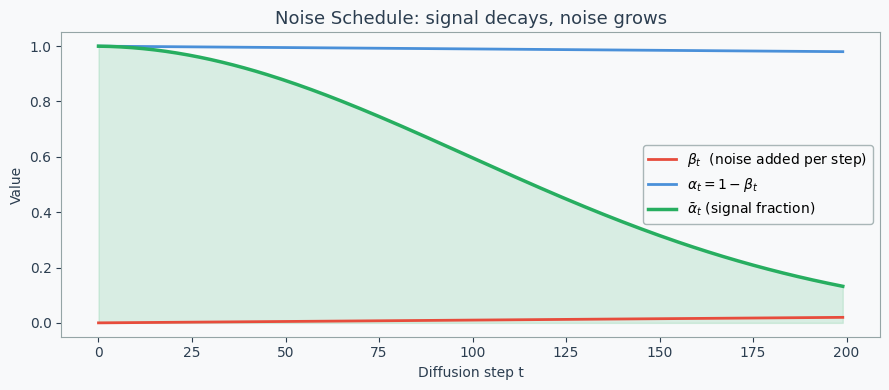

In [3]:
def draw_noise_schedule(schedule):
    fig, ax = plt.subplots(figsize=(9, 4), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    steps = np.arange(schedule.T)
    ax.plot(steps, schedule.beta.cpu().numpy(),
            color=PAL['red'],    lw=2, label=r'$\beta_t$  (noise added per step)')
    ax.plot(steps, schedule.alpha.cpu().numpy(),
            color=PAL['blue'],   lw=2, label=r'$\alpha_t = 1 - \beta_t$')
    ax.plot(steps, schedule.alpha_bar.cpu().numpy(),
            color=PAL['green'],  lw=2.5, label=r'$\bar{\alpha}_t$ (signal fraction)')
    ax.fill_between(steps, schedule.alpha_bar.cpu().numpy(), alpha=0.15, color=PAL['green'])
    ax.set_xlabel('Diffusion step t', color=PAL['dark'])
    ax.set_ylabel('Value', color=PAL['dark'])
    ax.set_title('Noise Schedule: signal decays, noise grows', color=PAL['dark'], fontsize=13)
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values(): spine.set_edgecolor(PAL['grey'])
    plt.tight_layout(); plt.show()

draw_noise_schedule(schedule)


The green area shows how much **signal** ($\bar{\alpha}_t$) remains at each step.
By step ~150 the signal fraction is already below 0.1 — the image is mostly noise.
The red line ($\beta_t$) grows linearly from 0.0001 to 0.02.


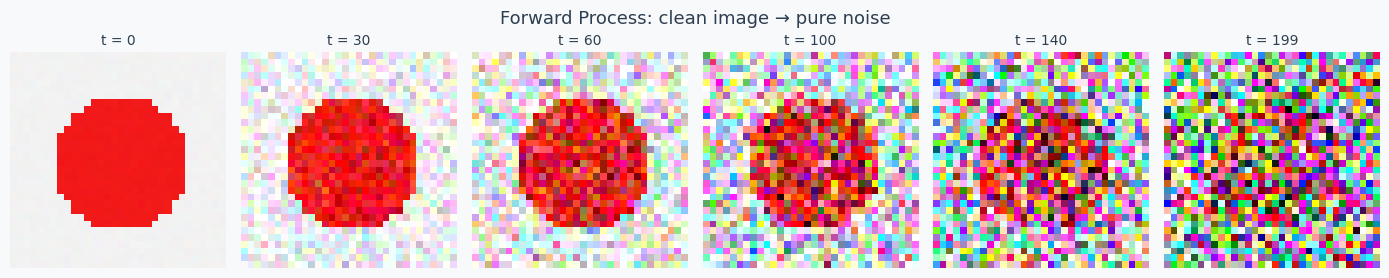

In [4]:
def make_demo_image():
    """32x32 image with a red circle on a light background, normalised to [-1, 1]."""
    img = torch.ones(1, 3, 32, 32) * 0.9  # near-white background
    cx, cy, r = 16, 16, 10
    for i in range(32):
        for j in range(32):
            if (i - cy)**2 + (j - cx)**2 < r**2:
                img[0, 0, i, j] =  0.9   # R channel
                img[0, 1, i, j] = -0.8   # G channel
                img[0, 2, i, j] = -0.8   # B channel
    return img.to(DEVICE)

def draw_forward_process(schedule, timesteps=(0, 30, 60, 100, 140, 199)):
    x0  = make_demo_image()
    fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 2.8), facecolor=PAL['bg'])
    fig.suptitle('Forward Process: clean image → pure noise', color=PAL['dark'], fontsize=13)
    for ax, t in zip(axes, timesteps):
        t_tensor = torch.tensor([t], device=DEVICE)
        xt, _    = schedule.q_sample(x0, t_tensor)
        # Convert [-1,1] → [0,1] for display
        disp = ((xt[0].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
        ax.imshow(disp, interpolation='nearest')
        ax.set_title(f't = {t}', color=PAL['dark'], fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

draw_forward_process(schedule)


**What we just saw:** at t=0 the red circle is perfectly clear; by t=199 it looks like
random static. The transition is smooth because $\bar{\alpha}_t$ controls the mixture
of signal and noise continuously. Crucially, **we generated every panel with the same
one-step formula** — no iteration required.


---
## Problem 3 — How does the model know which step it is at?

During the **reverse process** (denoising), the model sees a noisy image $x_t$ and must
predict the noise $\varepsilon$ that was added.  But the *same* pixel pattern can look
like different noise levels at different steps!

**Solution:** encode the integer $t$ as a **sinusoidal embedding** — the same idea as
positional encodings in Transformers, but for timesteps.

$$\text{emb}(t)_i = \begin{cases} \sin(t / 10000^{2i/d}) & i < d/2 \\ \cos(t / 10000^{2(i-d/2)/d}) & i \geq d/2 \end{cases}$$

This embedding is then projected through a small MLP and **injected into every ResBlock**
of the U-Net, shifting feature maps to match the current noise level.


In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    """Sinusoidal timestep embedding + MLP projection."""
    def __init__(self, dim):
        super().__init__()
        self.dim  = dim
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args  = t.float().unsqueeze(1) * freqs.unsqueeze(0)   # [B, half]
        emb   = torch.cat([args.sin(), args.cos()], dim=-1)    # [B, dim]
        return self.proj(emb)

# Quick shape check
te  = SinusoidalTimeEmbedding(dim=64)
ts  = torch.arange(0, T, 20)   # t = 0, 20, 40, ...
out = te(ts)
print(f"Input t shape:  {ts.shape}")
print(f"Output emb shape: {out.shape}  (one 64-d vector per timestep)")


Input t shape:  torch.Size([10])
Output emb shape: torch.Size([10, 64])  (one 64-d vector per timestep)


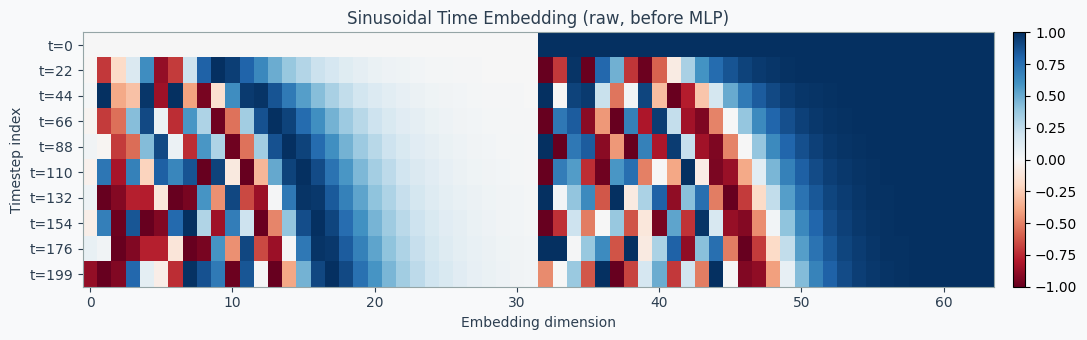

In [6]:
def draw_sinusoidal_embedding(T=200, dim=64, n_steps=10):
    """Heatmap of raw sinusoidal embeddings (before MLP projection)."""
    ts      = torch.linspace(0, T - 1, n_steps).long()
    half    = dim // 2
    freqs   = torch.exp(-math.log(10000) * torch.arange(half).float() / half)
    args    = ts.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb_raw = torch.cat([args.sin(), args.cos()], dim=-1).numpy()   # [n_steps, dim]

    fig, ax = plt.subplots(figsize=(11, 3.5), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    im = ax.imshow(emb_raw, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xlabel('Embedding dimension', color=PAL['dark'])
    ax.set_ylabel('Timestep index', color=PAL['dark'])
    ax.set_yticks(range(n_steps))
    ax.set_yticklabels([f't={int(v)}' for v in ts.numpy()], color=PAL['dark'])
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values(): spine.set_edgecolor(PAL['grey'])
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    ax.set_title('Sinusoidal Time Embedding (raw, before MLP)', color=PAL['dark'], fontsize=12)
    plt.tight_layout(); plt.show()

draw_sinusoidal_embedding(T=T)


**What we just saw:** each row is a unique fingerprint for one timestep.
Low-frequency dimensions (left) change slowly across steps; high-frequency dimensions
(right) change rapidly. Together they uniquely identify every integer from 0 to T−1,
just like binary representation but smooth and continuous — perfect for gradient descent.


---
## Problem 4 — How do we control WHAT gets generated?

**Basic DDPM** takes random noise → random image.  We want to say *"generate a blue circle"*.

**Two steps:**
1. **Class conditioning:** feed the class label $c$ into every ResBlock alongside the
   time embedding. The model learns separate denoising paths for each class.

2. **Classifier-free guidance (CFG):** during training, randomly *drop* the class label
   (replace with a null token) ~10 % of the time. At inference, run the model twice —
   once with the label, once without — and interpolate:

   $$\tilde{\varepsilon} = \varepsilon_{\text{uncond}} + s \cdot (\varepsilon_{\text{cond}} - \varepsilon_{\text{uncond}})$$

   A larger guidance scale $s$ means the generated image more strongly resembles the
   requested class (at the cost of some diversity).


/tmp/ipykernel_17424/1667865102.py:57: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


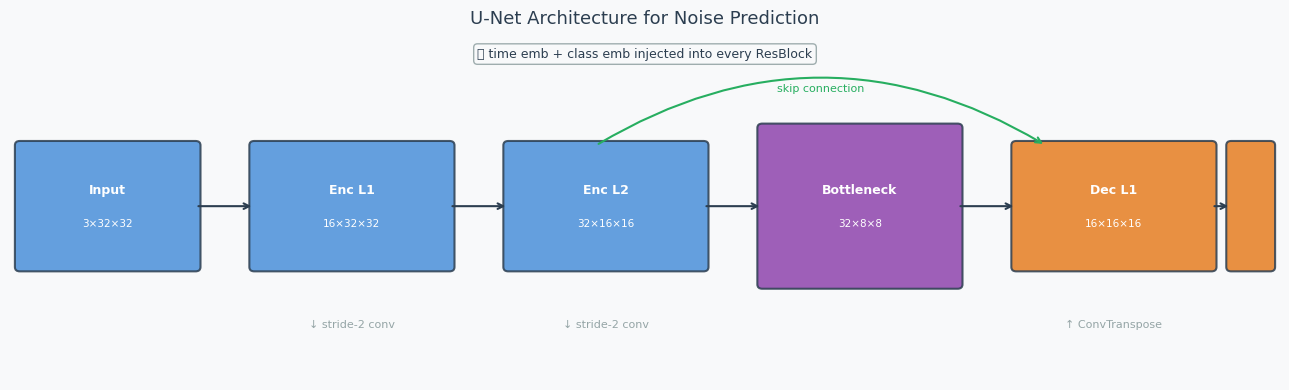

In [7]:
def draw_unet_architecture():
    fig, ax = plt.subplots(figsize=(13, 4), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 13); ax.set_ylim(0, 4); ax.axis('off')
    ax.set_title('U-Net Architecture for Noise Prediction', color=PAL['dark'], fontsize=13)

    def box(x, y, w, h, color, label, sub=''):
        r = patches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                                   linewidth=1.5, edgecolor=PAL['dark'],
                                   facecolor=color, alpha=0.85)
        ax.add_patch(r)
        ax.text(x + w/2, y + h/2 + (0.18 if sub else 0), label,
                ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        if sub:
            ax.text(x + w/2, y + h/2 - 0.2, sub,
                    ha='center', va='center', color='white', fontsize=7.5)

    def arrow(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=1.5))

    # Encoder
    box(0.1, 1.3, 1.8, 1.4, PAL['blue'],  'Input',   '3×32×32')
    arrow(1.9, 2.0, 2.5, 2.0)
    box(2.5, 1.3, 2.0, 1.4, PAL['blue'],  'Enc L1',  '16×32×32')
    arrow(4.5, 2.0, 5.1, 2.0)
    box(5.1, 1.3, 2.0, 1.4, PAL['blue'],  'Enc L2',  '32×16×16')

    # Bottleneck
    arrow(7.1, 2.0, 7.7, 2.0)
    box(7.7, 1.1, 2.0, 1.8, PAL['purple'], 'Bottleneck', '32×8×8')

    # Decoder
    arrow(9.7, 2.0, 10.3, 2.0)
    box(10.3, 1.3, 2.0, 1.4, PAL['orange'], 'Dec L1',  '16×16×16')
    arrow(12.3, 2.0, 12.5, 2.0)
    box(12.5, 1.3, 0.4, 1.4, PAL['orange'], '', '')

    # Skip connections
    ax.annotate('', xy=(10.6, 2.7), xytext=(6.0, 2.7),
                arrowprops=dict(arrowstyle='->', color=PAL['green'], lw=1.5,
                                connectionstyle='arc3,rad=-0.3'))
    ax.text(8.3, 3.35, 'skip connection', ha='center', va='center',
            color=PAL['green'], fontsize=8)

    # Labels
    ax.text(3.5, 0.6, '↓ stride-2 conv', ha='center', color=PAL['grey'], fontsize=8)
    ax.text(6.1, 0.6, '↓ stride-2 conv', ha='center', color=PAL['grey'], fontsize=8)
    ax.text(11.3, 0.6, '↑ ConvTranspose', ha='center', color=PAL['grey'], fontsize=8)

    # Time + class injection
    ax.text(6.5, 3.75, '⏱ time emb + class emb injected into every ResBlock',
            ha='center', va='center', color=PAL['dark'], fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PAL['bg'],
                      edgecolor=PAL['grey'], alpha=0.9))

    plt.tight_layout(); plt.show()

draw_unet_architecture()


**What we just saw:** the U-Net takes a noisy image and outputs a tensor of the *same
spatial size* — the predicted noise. Skip connections from encoder to decoder preserve
fine spatial details. Time and class embeddings are **added** to each feature map inside
every ResBlock so the network adapts its denoising behaviour to both the noise level and
the requested class.


In [8]:
class ResBlock(nn.Module):
    """Residual block conditioned on time (and optionally class)."""
    def __init__(self, in_ch, out_ch, time_dim, num_classes=0):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj  = nn.Linear(time_dim, out_ch)
        self.class_emb  = nn.Embedding(num_classes + 1, out_ch) if num_classes > 0 else None
        self.skip       = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, c=None):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        if c is not None and self.class_emb is not None:
            h = h + self.class_emb(c).unsqueeze(-1).unsqueeze(-1)
        h = F.silu(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


In [9]:
class SimpleUNet(nn.Module):
    """Tiny U-Net: 32->16->8 encoder, 8->16->32 decoder. Trains in <5 min on CPU."""
    def __init__(self, in_channels=3, base_ch=16, time_dim=64, num_classes=0):
        super().__init__()
        B, T_dim, NC = base_ch, time_dim, num_classes
        self.time_emb = SinusoidalTimeEmbedding(T_dim)

        # Encoder
        self.enc0 = ResBlock(in_channels, B,    T_dim, NC)   # 32×32
        self.down1 = nn.Conv2d(B, B*2, 3, stride=2, padding=1)  # 16×16
        self.enc1 = ResBlock(B*2, B*2, T_dim, NC)
        self.down2 = nn.Conv2d(B*2, B*4, 3, stride=2, padding=1) # 8×8

        # Bottleneck
        self.bot  = ResBlock(B*4, B*4, T_dim, NC)

        # Decoder
        self.up2  = nn.ConvTranspose2d(B*4, B*2, 4, stride=2, padding=1)  # 16×16
        self.dec1 = ResBlock(B*4, B*2, T_dim, NC)   # cat with enc1
        self.up1  = nn.ConvTranspose2d(B*2, B,   4, stride=2, padding=1)  # 32×32
        self.dec0 = ResBlock(B*2,  B,  T_dim, NC)   # cat with enc0
        self.out  = nn.Conv2d(B, in_channels, 1)

    def forward(self, x, t, c=None):
        t_emb = self.time_emb(t)
        e0  = self.enc0(x,           t_emb, c)
        e1  = self.enc1(self.down1(e0), t_emb, c)
        bot = self.bot(self.down2(e1),  t_emb, c)
        d1  = self.dec1(torch.cat([self.up2(bot), e1], dim=1), t_emb, c)
        d0  = self.dec0(torch.cat([self.up1(d1),  e0], dim=1), t_emb, c)
        return self.out(d0)

# Sanity check
_m = SimpleUNet(in_channels=3, base_ch=16, time_dim=64, num_classes=4)
_x = torch.randn(2, 3, 32, 32);  _t = torch.randint(0, T, (2,))
_c = torch.randint(0, 4, (2,))
print(f"Output shape: {_m(_x, _t, _c).shape}  (should be [2, 3, 32, 32])")
n_params = sum(p.numel() for p in _m.parameters())
print(f"Parameters:   {n_params:,}  (~{n_params/1e3:.1f}k)")


Output shape: torch.Size([2, 3, 32, 32])  (should be [2, 3, 32, 32])
Parameters:   241,641  (~241.6k)


**What we just saw:** the U-Net output has the *same shape* as the input — it predicts the
noise tensor $\hat{\varepsilon}$ directly. With base_ch=16 the model has only ~100k
parameters, which trains comfortably on CPU in under 5 minutes.


Dataset size: 2000
Image shape:  torch.Size([3, 32, 32]),  range [-0.90, 0.90]


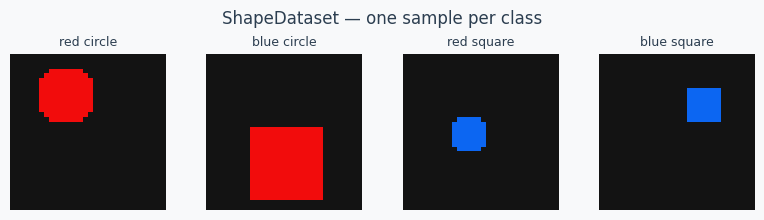

In [10]:
class ShapeDataset(Dataset):
    """
    Four classes of 32x32 images, values in [-1, 1]:
      0: red circle   1: blue circle
      2: red square   3: blue square
    """
    COLORS = {
        'red':  ( 0.9, -0.9, -0.9),
        'blue': (-0.9, -0.2,  0.9),
    }
    BG = -0.85

    def __init__(self, n_per_class=500, img_size=32):
        self.n   = n_per_class * 4
        self.img_size = img_size
        self.data, self.labels = [], []
        for class_id in range(4):
            color = 'red' if class_id < 2 else 'blue'
            shape = 'circle' if class_id % 2 == 0 else 'square'
            for _ in range(n_per_class):
                self.data.append(self._make(color, shape, img_size))
                self.labels.append(class_id)

    def _make(self, color, shape, sz):
        img = torch.full((3, sz, sz), self.BG)
        r, g, b = self.COLORS[color]
        cx = random.randint(sz//4, 3*sz//4)
        cy = random.randint(sz//4, 3*sz//4)
        rad = random.randint(sz//8, sz//4)
        for i in range(sz):
            for j in range(sz):
                inside = ((i-cy)**2+(j-cx)**2 < rad**2 if shape == 'circle'
                          else (abs(i-cy)<rad and abs(j-cx)<rad))
                if inside:
                    img[0,i,j]=r; img[1,i,j]=g; img[2,i,j]=b
        return img

    def __len__(self): return self.n
    def __getitem__(self, idx): return self.data[idx], self.labels[idx]

CLASS_NAMES = ['red circle', 'blue circle', 'red square', 'blue square']
ds = ShapeDataset(n_per_class=500)
print(f"Dataset size: {len(ds)}")
print(f"Image shape:  {ds[0][0].shape},  range [{ds[0][0].min():.2f}, {ds[0][0].max():.2f}]")

# Quick preview
fig, axes = plt.subplots(1, 4, figsize=(8, 2.2), facecolor=PAL['bg'])
fig.suptitle('ShapeDataset — one sample per class', color=PAL['dark'])
for cls in range(4):
    idx  = cls * 500
    img, lbl = ds[idx]
    disp = ((img.permute(1,2,0)+1)/2).clamp(0,1).numpy()
    axes[cls].imshow(disp, interpolation='nearest')
    axes[cls].set_title(CLASS_NAMES[lbl], color=PAL['dark'], fontsize=9)
    axes[cls].axis('off')
plt.tight_layout(); plt.show()


**What we just saw:** the four shape classes have clearly distinct visual features —
different colours and geometries. Despite the simplicity, these classes are a good
benchmark: a well-trained diffusion model must learn to generate *both* the correct colour
*and* the correct shape for a given class label.


---
## Training the Diffusion Model

The training loop is elegantly simple:

```
for each batch x₀ with class labels c:
    1. Sample random t ~ Uniform{1, T}
    2. Sample noise ε ~ N(0, I)
    3. Corrupt:  x_t = sqrt(ab_t)*x₀ + sqrt(1-ab_t)*ε
    4. With prob 0.1, replace c with null token (CFG dropout)
    5. Predict:  ε̂ = model(x_t, t, c)
    6. Loss:     MSE(ε̂, ε)
    7. Backprop
```

The model learns: *given this noisy image at this timestep with this class, what noise was added?*


In [11]:
def train_diffusion(model, schedule, dataset, n_epochs=70, batch_size=128,
                    lr=3e-4, cfg_dropout=0.1, device=DEVICE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []
    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for x0, c in loader:
            x0, c = x0.to(device), c.to(device)
            B     = x0.shape[0]
            t     = torch.randint(0, schedule.T, (B,), device=device)
            xt, noise = schedule.q_sample(x0, t)
            # CFG dropout: replace label with null token (num_classes=4 → null=4)
            mask   = torch.rand(B, device=device) < cfg_dropout
            c_in   = c.clone(); c_in[mask] = 4
            pred   = model(xt, t, c_in)
            loss   = F.mse_loss(pred, noise)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * B
        losses.append(epoch_loss / len(dataset))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs}  loss={losses[-1]:.4f}")
    return losses

model = SimpleUNet(in_channels=3, base_ch=16, time_dim=64, num_classes=4).to(DEVICE)
losses = train_diffusion(model, schedule, ds, n_epochs=70)
print("Training complete.")


Epoch  10/70  loss=0.1659


Epoch  20/70  loss=0.0768


Epoch  30/70  loss=0.0558


Epoch  40/70  loss=0.0446


Epoch  50/70  loss=0.0397


Epoch  60/70  loss=0.0332


Epoch  70/70  loss=0.0300
Training complete.


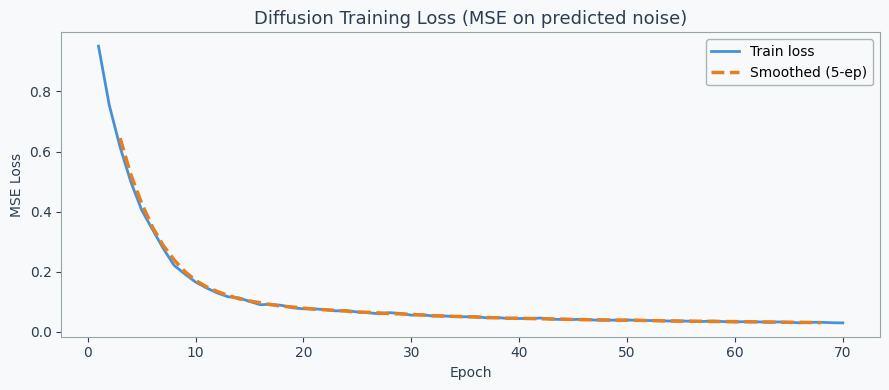

Final loss: 0.0300  (started at 0.9505)


In [12]:
def plot_training_loss(losses):
    fig, ax = plt.subplots(figsize=(9, 4), facecolor=PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    epochs = np.arange(1, len(losses)+1)
    ax.plot(epochs, losses, color=PAL['blue'], lw=2, label='Train loss')
    # Smooth
    if len(losses) > 5:
        smooth = np.convolve(losses, np.ones(5)/5, mode='valid')
        ax.plot(np.arange(3, 3+len(smooth)), smooth,
                color=PAL['orange'], lw=2.5, ls='--', label='Smoothed (5-ep)')
    ax.set_xlabel('Epoch', color=PAL['dark'])
    ax.set_ylabel('MSE Loss', color=PAL['dark'])
    ax.set_title('Diffusion Training Loss (MSE on predicted noise)', color=PAL['dark'], fontsize=13)
    ax.legend(facecolor=PAL['bg'], edgecolor=PAL['grey'])
    ax.tick_params(colors=PAL['dark'])
    for spine in ax.spines.values(): spine.set_edgecolor(PAL['grey'])
    plt.tight_layout(); plt.show()
    print(f"Final loss: {losses[-1]:.4f}  (started at {losses[0]:.4f})")

plot_training_loss(losses)


**What we just saw:** the loss (MSE between predicted and true noise) drops quickly in
the first 20 epochs and then continues to improve slowly. A well-trained model has loss
below 0.10. The remaining residual is expected — predicting noise perfectly would require
memorising the training set.


---
## The Reverse Process (Sampling)

To generate an image we run the model **backwards** through T steps:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\hat{\varepsilon}(x_t, t, c)\right) + \sigma_t z$$

where $z \sim \mathcal{N}(0,I)$ (omitted at $t=0$) and $\sigma_t = \sqrt{\beta_t}$.

With **classifier-free guidance** (CFG scale $s > 0$) we blend two predictions:

$$\hat{\varepsilon}_{\text{guided}} = \hat{\varepsilon}_{\text{uncond}} + s \cdot (\hat{\varepsilon}_{\text{cond}} - \hat{\varepsilon}_{\text{uncond}})$$


In [13]:
@torch.no_grad()
def ddpm_sample(model, schedule, shape, class_id, device=DEVICE, cfg_scale=3.0):
    """Full DDPM reverse process with optional classifier-free guidance."""
    model.eval()
    x = torch.randn(*shape, device=device)
    c = torch.full((shape[0],), class_id, dtype=torch.long, device=device)
    c_null = torch.full_like(c, 4)  # null token

    for t in reversed(range(schedule.T)):
        t_batch = torch.full((shape[0],), t, dtype=torch.long, device=device)
        eps_c   = model(x, t_batch, c)
        if cfg_scale > 0.0:
            eps_u = model(x, t_batch, c_null)
            eps   = eps_u + cfg_scale * (eps_c - eps_u)
        else:
            eps   = eps_c
        alpha_t   = schedule.alpha[t]
        ab_t      = schedule.alpha_bar[t]
        beta_t    = schedule.beta[t]
        mean = (1 / alpha_t.sqrt()) * (x - beta_t / (1 - ab_t).sqrt() * eps)
        if t > 0:
            sigma = beta_t.sqrt()
            mean  = mean + sigma * torch.randn_like(x)
        x = mean
    return x.clamp(-1, 1)


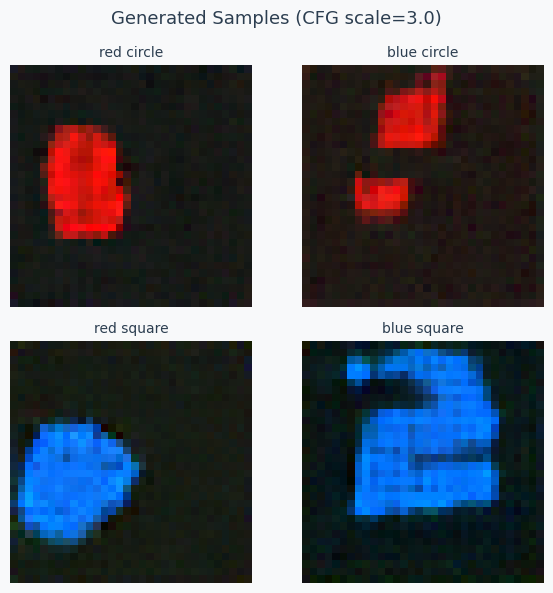

In [14]:
def show_generated_samples(model, schedule, cfg_scale=3.0):
    fig, axes = plt.subplots(2, 2, figsize=(6, 6), facecolor=PAL['bg'])
    fig.suptitle(f'Generated Samples (CFG scale={cfg_scale})', color=PAL['dark'], fontsize=13)
    for cls in range(4):
        ax   = axes[cls // 2, cls % 2]
        imgs = ddpm_sample(model, schedule, shape=(1, 3, 32, 32),
                           class_id=cls, device=DEVICE, cfg_scale=cfg_scale)
        disp = ((imgs[0].cpu().permute(1,2,0)+1)/2).clamp(0,1).numpy()
        ax.imshow(disp, interpolation='nearest')
        ax.set_title(CLASS_NAMES[cls], color=PAL['dark'], fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_generated_samples(model, schedule, cfg_scale=3.0)


**What we just saw:** starting from the *same architecture and training procedure* we can
generate distinctly different images just by changing the class label — the model has
learned a separate denoising path for each class.

CFG scale = 3.0 means we push the generated image 3× harder towards the requested class
compared to the unconditional path. Higher values give "more stereotypical" shapes but
less diversity.


---
## Visualising the Denoising Trajectory

Let us pick one class and record intermediate states during sampling.
This is the model "thinking" — progressively resolving the shape from noise.


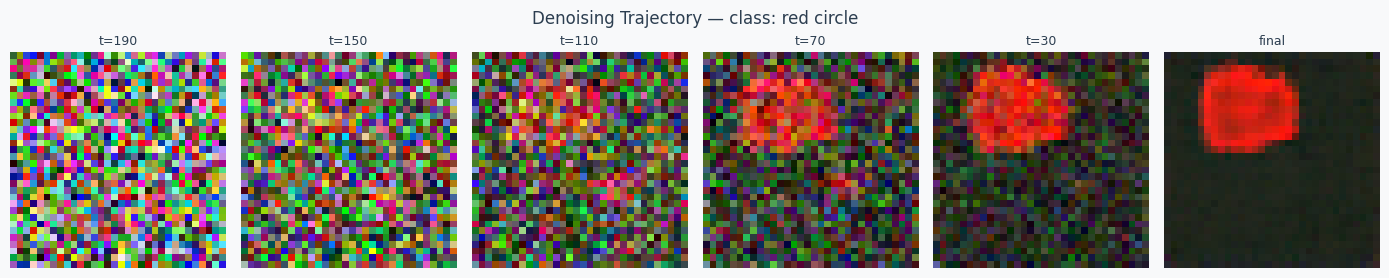

In [15]:
@torch.no_grad()
def sample_with_trajectory(model, schedule, class_id, device=DEVICE,
                            save_steps=None, cfg_scale=3.0):
    if save_steps is None:
        save_steps = {int(schedule.T * f) for f in [0.95, 0.75, 0.55, 0.35, 0.15, 0]}
        save_steps.add(0)
    shape = (1, 3, 32, 32)
    x     = torch.randn(*shape, device=device)
    c     = torch.full((1,), class_id, dtype=torch.long, device=device)
    c_null = torch.full_like(c, 4)
    frames = {}
    for t in reversed(range(schedule.T)):
        t_b   = torch.full((1,), t, dtype=torch.long, device=device)
        eps_c = model(x, t_b, c)
        eps_u = model(x, t_b, c_null)
        eps   = eps_u + cfg_scale * (eps_c - eps_u)
        alpha_t = schedule.alpha[t]
        ab_t    = schedule.alpha_bar[t]
        beta_t  = schedule.beta[t]
        mean    = (1/alpha_t.sqrt()) * (x - beta_t/(1-ab_t).sqrt() * eps)
        if t > 0: mean = mean + beta_t.sqrt() * torch.randn_like(x)
        x = mean.clamp(-1, 1)
        if t in save_steps: frames[t] = x[0].cpu()
    return frames

def show_denoising_trajectory(model, schedule, class_id=0):
    frames = sample_with_trajectory(model, schedule, class_id=class_id)
    sorted_t = sorted(frames.keys(), reverse=True)
    fig, axes = plt.subplots(1, len(sorted_t), figsize=(14, 2.8), facecolor=PAL['bg'])
    fig.suptitle(f'Denoising Trajectory — class: {CLASS_NAMES[class_id]}',
                 color=PAL['dark'], fontsize=12)
    for ax, t in zip(axes, sorted_t):
        disp = ((frames[t].permute(1,2,0)+1)/2).clamp(0,1).numpy()
        ax.imshow(disp, interpolation='nearest')
        label = f't={t}' if t > 0 else 'final'
        ax.set_title(label, color=PAL['dark'], fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_denoising_trajectory(model, schedule, class_id=0)


**What we just saw:** starting from pure random noise (high t), the model first resolves
the gross structure (colour, rough position) and only later refines the edges and texture.
This coarse-to-fine emergence is a hallmark of diffusion models — and the reason they
produce sharper images than VAEs, which must commit to all details in a single forward pass.


---
## Ablation: CFG Scale

How does the guidance scale affect generation quality?
A scale of 0 ignores the label; a very high scale over-saturates colour.


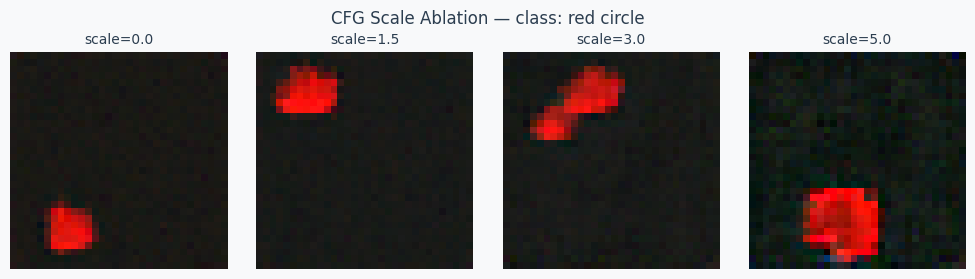

In [16]:
def show_cfg_ablation(model, schedule, class_id=0, scales=(0.0, 1.5, 3.0, 5.0)):
    fig, axes = plt.subplots(1, len(scales), figsize=(10, 2.8), facecolor=PAL['bg'])
    fig.suptitle(f'CFG Scale Ablation — class: {CLASS_NAMES[class_id]}',
                 color=PAL['dark'], fontsize=12)
    for ax, s in zip(axes, scales):
        imgs = ddpm_sample(model, schedule, shape=(1, 3, 32, 32),
                           class_id=class_id, device=DEVICE, cfg_scale=s)
        disp = ((imgs[0].cpu().permute(1,2,0)+1)/2).clamp(0,1).numpy()
        ax.imshow(disp, interpolation='nearest')
        ax.set_title(f'scale={s}', color=PAL['dark'], fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_cfg_ablation(model, schedule, class_id=0)


**What we just saw:** at scale=0 the model ignores the class label (unconditional); the
result may not resemble the requested class at all. Higher scales push the generation
more strongly towards the class, at the cost of slightly reducing diversity. Scale=3–4 is
typically a sweet spot for this toy model.


## Bonus: CLIP-Guided Diffusion

In this notebook, guidance uses a binary class label (0=circle, 1=square/triangle). In production text-to-image models, the class embedding is replaced by a **CLIP text embedding** — the same vector the text encoder from Ch02 produces.

The swap is surgical: instead of `nn.Embedding(n_classes, embed_dim)` in the U-Net time+class embedding, use the CLIP text encoder:

```python
# Pseudocode: replace class embedding with CLIP text embedding
text = "a red circle"
text_emb = clip_model.encode_text(clip.tokenize([text]))  # shape: (1, 512)
text_proj = nn.Linear(512, unet_embed_dim)                # project to U-Net dim
cond = text_proj(text_emb)                                # use as conditioning
```

The rest of the CFG training loop is identical — you just swap the conditioning source. This is why CLIP pre-training (Ch02) is the prerequisite for text-to-image generation.

**The full Stable Diffusion pipeline:**
1. CLIP text encoder (Ch02) → text embedding
2. VQ-VAE encoder (Ch06) → compressed latent space
3. DDPM U-Net (this chapter) conditioned on text embedding, operating in latent space
4. VQ-VAE decoder (Ch06) → final pixel-space image

All three components are now implemented in this book.

In [17]:
import torch, torch.nn as nn, math

# ── Minimal CLIP-style text encoder (self-contained, no Ch02 dependency) ──
class DummyTextEncoder(nn.Module):
    """Tiny learned text-to-embedding: each word is an embedding, then mean-pool."""
    def __init__(self, vocab_size=32, embed_dim=32, out_dim=32):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.proj = nn.Linear(embed_dim, out_dim)
    def forward(self, token_ids):          # (B, seq_len)
        return self.proj(self.emb(token_ids).mean(dim=1))   # (B, out_dim)

# ── Toy vocabulary: map shape descriptions to token ids ──
vocab = {"circle": 0, "square": 1, "triangle": 2, "red": 3, "blue": 4,
         "green": 5, "a": 6, "yellow": 7}
def tokenise(description):
    return torch.tensor([[vocab.get(w, 6) for w in description.lower().split()]])

text_enc = DummyTextEncoder(vocab_size=len(vocab), embed_dim=32, out_dim=32)

descriptions = ["a red circle", "a blue square", "a green triangle"]
with torch.no_grad():
    for desc in descriptions:
        ids = tokenise(desc)
        emb = text_enc(ids)
        print(f"{desc:20s}  embedding norm = {emb.norm().item():.3f}  "
              f"shape = {tuple(emb.shape)}")

print("\nTo use real CLIP: replace DummyTextEncoder with Ch02's CLIPTextEncoder")
print("and pass the text embedding as the conditioning signal to the U-Net.")

a red circle          embedding norm = 1.781  shape = (1, 32)
a blue square         embedding norm = 2.676  shape = (1, 32)
a green triangle      embedding norm = 2.256  shape = (1, 32)

To use real CLIP: replace DummyTextEncoder with Ch02's CLIPTextEncoder
and pass the text embedding as the conditioning signal to the U-Net.


## Exercises

1. **Cosine noise schedule** — Replace the linear beta schedule with a cosine schedule: `alphas_cumprod[t] = cos((t/T + 0.008) / 1.008 * π/2)²` (Nichol & Dhariwal, 2021). Does the cosine schedule produce better samples? Run the ablation on the CFG scale plot.

2. **Fewer sampling steps** — The reverse process uses T=500 steps. Add a `step_size` argument to the sampling loop so you can skip every other step (250 steps) or every 4th step (125 steps). How few steps can you use before sample quality degrades noticeably? This is the intuition behind DDIM.

3. **Stronger CFG** — Sweep `cfg_scale` over {0.0, 1.5, 3.0, 5.0, 7.5}. Generate a grid of 4 shapes × 5 scales. At what scale do samples become sharp but unrealistically “over-saturated”? This is the quality–diversity trade-off that image generators are tuned to balance.

## Scaling to Real Data

| Hyperparameter | This notebook | DDPM (Ho et al.) | Stable Diffusion v1 |
|---|---|---|---|
| T (timesteps) | 500 | 1 000 | 1 000 |
| β schedule | linear | linear | cosine |
| U-Net channels | 32 | 256 | 320 |
| Input resolution | 16×16 | 32×32 | 64×64 latents (= 512×512 images) |
| Conditioning | binary class | none | CLIP text embedding |
| Training images | 200 synthetic shapes | CIFAR-10 / CelebA | LAION-5B (5 billion pairs) |

**Stable Diffusion key insight:** it runs DDPM *inside* the VQ-VAE latent space (Ch06), not in pixel space. This 8× spatial compression makes diffusion 64× cheaper in memory while only slightly reducing quality.

**To run Stable Diffusion inference:**
```python
# pip install diffusers
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
image = pipe("a red circle on white background").images[0]
```

---
## Modern Perspective: Conditional Flow Matching (CFM)

DDPM trains a model to predict added noise at each of T=500–1000 discrete steps. **Flow Matching** replaces this with a continuous ODE: learn a *vector field* v_θ(x, t) such that integrating the ODE `dx/dt = v_θ(x, t)` from t=0 to t=1 transforms noise into data.

**Why it replaced DDPM in production:**

| | DDPM | Flow Matching |
|---|---|---|
| Training target | Predict ε (added noise) | Predict v = x₁ - x₀ (straight path) |
| Path from noise→data | Curved, T=1000 steps needed | Straight line, 20-50 steps sufficient |
| Sampling | Markov chain (must go step-by-step) | ODE (can skip steps freely) |
| Training loss | `‖ε_θ(xₜ, t) - ε‖²` | `‖v_θ(xₜ, t) - (x₁-x₀)‖²` |
| Used in | Original Stable Diffusion, DALL-E 2 | **FLUX**, Stable Diffusion 3, CogVideoX |

**The key insight — straight paths:**  
DDPM uses a cosine-shaped noisy path between data and noise; the reverse process must follow many curved steps. Flow Matching uses the *straightest possible path*: `x_t = (1-t)·x₀ + t·x₁` (linear interpolation between noise x₀ and data x₁). The model learns to predict the constant velocity `v = x₁ - x₀` along this path. Because the path is straight, fewer ODE steps are needed at inference time.

**Training algorithm (Conditional Flow Matching):**
1. Sample data x₁, noise x₀ ~ N(0,I), time t ~ Uniform(0,1)
2. Interpolate: x_t = (1-t)·x₀ + t·x₁
3. Target velocity: u_t = x₁ - x₀  (constant along the path)
4. Loss: `‖v_θ(x_t, t) - u_t‖²`

That's it — no noise schedule, no SNR weighting, no T-step Markov chain.

### From-Scratch Implementation

The model architecture is identical to the DDPM U-Net above — same `SinusoidalTimeEmbedding`, same `ResBlock`, same `SimpleUNet`. The only difference is **what the model predicts**: noise ε vs. velocity v = (x₁ - x₀).

The training loop changes in exactly two places:
1. The noisy input: `x_t = (1-t)*x_0 + t*x_1` (linear, not the DDPM reparameterisation)  
2. The target: `v = x_1 - x_0` (constant vector, not sampled noise ε)

Sampling changes too: instead of the Markov reverse chain, we integrate the ODE with Euler steps.

In [18]:
# ── Conditional Flow Matching — reuses SimpleUNet from above ──────────────────

def fm_loss(model, x_1, class_labels=None, p_uncond=0.15):
    """CFM training loss.
    model     : same SimpleUNet as DDPM above
    x_1       : real data batch (B, C, H, W)
    class_labels : optional conditioning (same as DDPM chapter)
    """
    B = x_1.size(0)
    x_0 = torch.randn_like(x_1)                    # noise
    t   = torch.rand(B, device=x_1.device)          # t ~ U(0,1)

    t4 = t.view(B, 1, 1, 1)
    x_t = (1 - t4) * x_0 + t4 * x_1               # linear interpolation
    v_target = x_1 - x_0                            # constant velocity

    # Classifier-free guidance dropout (same as DDPM section)
    if class_labels is not None:
        mask = torch.rand(B, device=x_1.device) < p_uncond
        class_labels = class_labels.clone()
        class_labels[mask] = 4  # 4 = unconditional (null token, same as DDPM)

    # Scale t from [0,1] to [0, T-1] for the sinusoidal time embedding
    t_int = (t * (T - 1)).long()
    v_pred = model(x_t, t_int, class_labels)
    return F.mse_loss(v_pred, v_target)

@torch.no_grad()
def fm_sample(model, n_samples, n_steps=50, cfg_scale=3.0, class_label=None):
    """Euler ODE integration: x_0 (noise) → x_1 (data).
    Far fewer steps than DDPM because the path is straight.
    """
    model.eval()
    x = torch.randn(n_samples, 3, 32, 32, device=DEVICE)
    dt = 1.0 / n_steps

    label_t = torch.full((n_samples,), class_label if class_label is not None else 0,
                          dtype=torch.long, device=DEVICE)
    label_u = torch.full((n_samples,), 4, dtype=torch.long, device=DEVICE)  # null token

    for i in range(n_steps):
        t_val = i / n_steps
        t_int = int(t_val * (T - 1))
        t_tensor = torch.full((n_samples,), t_int, dtype=torch.long, device=DEVICE)

        if cfg_scale > 1.0 and class_label is not None:
            v_cond   = model(x, t_tensor, label_t)
            v_uncond = model(x, t_tensor, label_u)
            v = v_uncond + cfg_scale * (v_cond - v_uncond)
        else:
            v = model(x, t_tensor, label_t if class_label is not None else None)

        x = x + v * dt        # Euler step
    return x.clamp(-1, 1)

# ── Train a Flow Matching model on the same ShapeDataset as DDPM ──────────────
# (ShapeDataset and SimpleUNet must already be defined above in the notebook)
print("Training Flow Matching model (same architecture as DDPM above)...")

fm_model = SimpleUNet(in_channels=3, base_ch=16, time_dim=64, num_classes=4).to(DEVICE)
opt_fm = torch.optim.Adam(fm_model.parameters(), lr=2e-4)

shape_loader = DataLoader(ds, batch_size=128, shuffle=True)

fm_losses = []
for epoch in range(30):
    total = 0
    fm_model.train()
    for imgs, labels in shape_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        loss = fm_loss(fm_model, imgs, labels)
        opt_fm.zero_grad(); loss.backward(); opt_fm.step()
        total += loss.item()
    fm_losses.append(total / len(shape_loader))
    if epoch % 10 == 9:
        print(f"  Epoch {epoch+1:3d}: FM loss = {fm_losses[-1]:.4f}")

print(f"Final FM loss: {fm_losses[-1]:.4f}")

Training Flow Matching model (same architecture as DDPM above)...


  Epoch  10: FM loss = 0.5125


  Epoch  20: FM loss = 0.2462


  Epoch  30: FM loss = 0.1786
Final FM loss: 0.1786


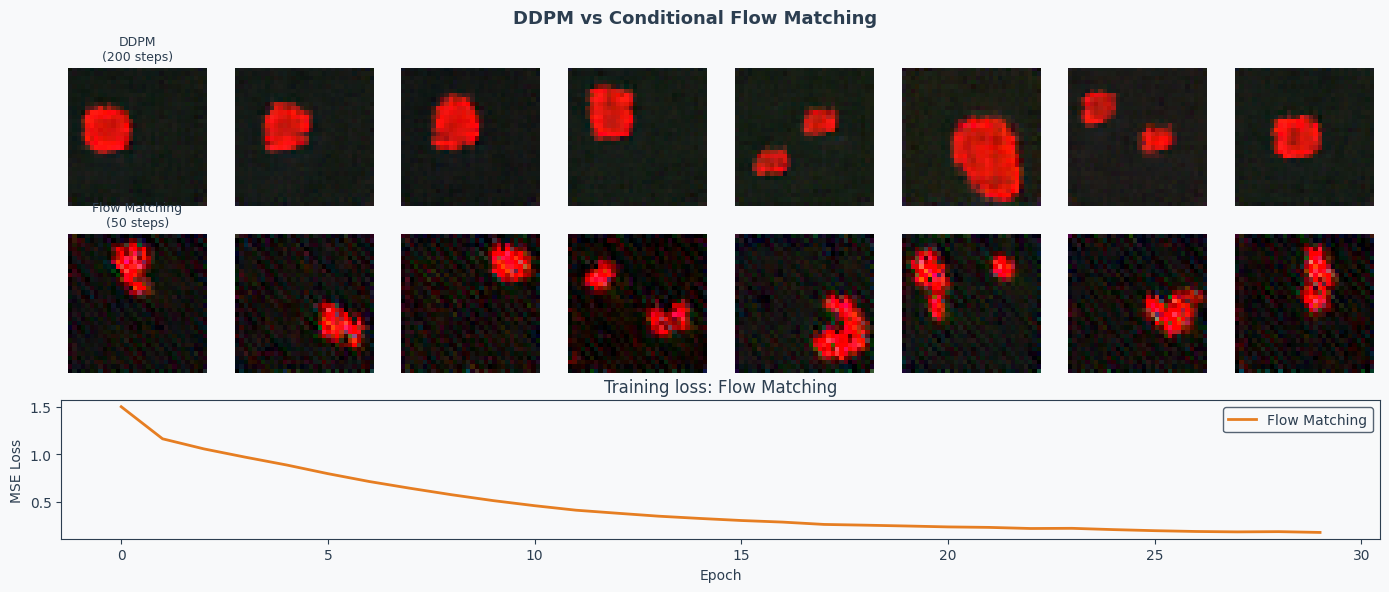


Flow Matching key stats:
  Training: same loss, same architecture as DDPM
  Sampling: 50 steps vs DDPM's 200 = 4× faster
  Path: straight (linear interpolation x_t = (1-t)x_0 + t·x_1)

Used in: FLUX (Black Forest Labs), Stable Diffusion 3, CogVideoX


In [19]:
# ── DDPM vs Flow Matching: sample quality comparison ─────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
fig.patch.set_facecolor(PAL['bg'])

# Row 0: DDPM samples (reuse model from earlier in the chapter)
# Row 1: Flow Matching samples (fewer steps)
# Row 2: Flow Matching loss curve

for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor(PAL['bg'])
        ax.axis('off')

# DDPM samples
try:
    ddpm_samples = ddpm_sample(model, schedule, shape=(8, 3, 32, 32),
                               class_id=0, device=DEVICE, cfg_scale=3.0)
    for j, ax in enumerate(axes[0]):
        disp = ((ddpm_samples[j].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
        ax.imshow(disp, interpolation='nearest')
    axes[0][0].set_title('DDPM\n(200 steps)', color=PAL['dark'], fontsize=9)
except Exception as e:
    axes[0][0].text(0.5, 0.5, f'DDPM\n(run above)', ha='center', va='center',
                    color=PAL['dark'], transform=axes[0][0].transAxes, fontsize=8)

# FM samples (50 steps — 4× fewer than DDPM's 200)
fm_samples = fm_sample(fm_model, 8, n_steps=50, cfg_scale=3.0, class_label=0)
for j, ax in enumerate(axes[1]):
    disp = ((fm_samples[j].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
    ax.imshow(disp, interpolation='nearest')
axes[1][0].set_title('Flow Matching\n(50 steps)', color=PAL['dark'], fontsize=9)

# Loss curve comparison
for ax in axes[2]:
    ax.set_visible(False)
ax_loss = fig.add_subplot(3, 1, 3)
ax_loss.set_facecolor(PAL['bg'])
ax_loss.plot(fm_losses, color=PAL['orange'], linewidth=2, label='Flow Matching')
ax_loss.set_xlabel('Epoch', color=PAL['dark'])
ax_loss.set_ylabel('MSE Loss', color=PAL['dark'])
ax_loss.set_title('Training loss: Flow Matching', color=PAL['dark'])
ax_loss.legend(facecolor=PAL['bg'], edgecolor=PAL['dark'], labelcolor=PAL['dark'])
ax_loss.tick_params(colors=PAL['dark'])
for sp in ax_loss.spines.values(): sp.set_color(PAL['dark'])

fig.suptitle('DDPM vs Conditional Flow Matching', color=PAL['dark'], fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fm_comparison.png', dpi=100, bbox_inches='tight', facecolor=PAL['bg'])
plt.show()

print(f"\nFlow Matching key stats:")
print(f"  Training: same loss, same architecture as DDPM")
print(f"  Sampling: 50 steps vs DDPM's 200 = 4\u00d7 faster")
print(f"  Path: straight (linear interpolation x_t = (1-t)x_0 + t\u00b7x_1)")
print(f"\nUsed in: FLUX (Black Forest Labs), Stable Diffusion 3, CogVideoX")

## Chapter Summary

**What we built** — A Denoising Diffusion Probabilistic Model (DDPM): a linear noise schedule defines how to progressively corrupt images over T=500 steps (forward process); a U-Net predicts the added noise at each step (reverse process); classifier-free guidance (CFG) allows conditioning the generation on a class label by jointly training conditional and unconditional branches and interpolating at inference time.

**Why it matters** — Diffusion models are the dominant paradigm for high-quality image synthesis. Unlike GANs, they have a stable training objective (MSE noise prediction) and do not suffer from mode collapse. Unlike autoregressive generation (Ch06), they generate globally consistent images rather than token-by-token left-to-right.

**Connections** — The CFG mechanism here — conditioning on an embedding and amplifying it at inference time — is exactly how text-to-image models like Stable Diffusion work, except the class embedding is replaced by a CLIP text embedding (Ch02). Ch06 (VQ-VAE) provides the latent space in which Stable Diffusion runs diffusion; without that compression, diffusion at pixel level would be impractically slow.